[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Jibby2k1/SPS_Curriculum/blob/main/Intro_DL_4_Physics/intro_transformers/intro_transformers_blank.ipynb)

**Content Produced by UF Signal Processing Society**

**Authors: Awwab Azam**

Credit: ~~I have used the official PyTorch tutorial (https://docs.pytorch.org/tutorials/beginner/basics/intro.html) for part of this workshop~~

# Intro to Deep Learning using PyTorch

This is the second of a planned 3-part series covering the basics of deep learning for applications in Physics and Engineering. In this workshop, we will learn how the self-attention mechanism works and code a transformer model (the architecture underpinning modern LLMs) from scratch. Let's get started!

### Setup

For this tutorial, we will need several Python packages, including PyTorch, NumPy, and MatplotLib. If you are not very tech-savvy, the easiest thing to do would be to open this notebook in Google Colab using the link at the top. Google Colab is an online cloud-based development environment that comes with all these packages preinstalled.

For those who are comfortable working with Python virtual environments and would like to run the code locally, please make sure you have all the packages in the import section installed.

## 0. Getting started

First we need to import the packages that we want to use.

In [1]:
# imports
import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader
import numpy as np
import matplotlib.pyplot as plt
from typing import Tuple
import json

In [2]:
# to use GPU acceleration if available
# if torch.backends.mps.is_available():
#     device = torch.device("mps")
# else:
#     print("MPS device not found.")
#     device = torch.device("cpu")
device = torch.device("cpu")
print(f"Using device: {device}")

Using device: cpu


## 1. Generating data

There are a plethora of real-world tasks for which Transformers can be a good use case. Basically, for anything where you're dealing with sequences of vectors or objects that can be transformed into vectors (e.g. images), and you need to model some kind of complex interactions between the elements of the input sequence, transformers could come in handy.

For this workshop, we will training our transformer model on a toy task that has zero practical applications, but is still useful for pedagogical purposes, namely a feature-wise softmax function across a sequence of vectors.

Anyhow, first we need to generate our input and output data:

In [ ]:
# --- Configuration ---
NUM_SAMPLES = 100_000
SEQUENCE_LENGTH = 16  # How many vectors in a sequence
VECTOR_DIM = 3  # Each vector will be 3D (e.g., an [x, y, z] vector)

# ... DATA GENERATION CODE GOES HERE


torch.Size([100000, 2, 16, 3])


As before, we need to standardize our data to have zero mean and unit variance to help our model learn effectively:

In [ ]:
# standardize our data to have 0 mean and unit variance
def normalize(x, mean, std_dev):
    return (x - mean) / std_dev


def denormalize(x, mean, std_dev):
    return (x * std_dev) + mean


# code to get normalization constants, apply them to the data, etc.

# write normalization constants to a JSON file so that we can load them later


Normalization Constants: 
Inputs mean: 0.0005035785143263638 || Inputs Standard Deviation: 0.9999176859855652
Outputs mean: 0.0625 || Outputs Standard Deviation: 0.06605560332536697


... and also save it to disk so that we can load it later if need be.

In [ ]:
# save to disk


Now, we have to make our custom Dataset class:

In [ ]:
# make our Dataset class


We can test that it's working properly by wrapping it in a toy dataloader:

Input batch shape: torch.Size([5, 16, 3])
Output batch shape: torch.Size([5, 16, 3])


## 2. Building the Transformer

OK, now this is the actual fun part. Essentially, a transformer model consists of alternating *attention blocks*, which capture relationships between the vectors in a sequence, and *feedforward layers*, which are standard multilayer perceptrons that transform their input vectors into a new representation of the information. But before we dig into the details, it is important to note that by their very nature, transformers are position-equivariant. By that we mean that - unlike normal MLPs or CNNs, for example - they don't know about the positions of input vectors. As such, we have to manually inject positional information into the model. There are a multitude of ways to do this, including RoPE, sinusoidal, learned, and relative positional encodings, but for the purposes of this workshop, we'll just use the simplest way (and the orignal formulation in the "Attention is All You Need" paper), which is sinusoidal positional encodings.

Basically, this transforms each input vector by adding it to a positional embedding vector $PE$, which is a function of the vector's position that is computed as:

$$PE(pos, 2i) = sin\left( \frac{pos}{n^{2i/d}} \right)$$
$$PE(pos, 2i+1) = cos\left( \frac{pos}{n^{2i/d}} \right)$$

where $d$ is the embedding dimension of the model, $i \in \{1, 2, ... \frac{d}{2}\}$ is used to index the elements of $PE$, and $n$ is a scaling factor that was chosen to $=1000$ in the original Transformer paper (based on empirical data), which is what we will be going with for this workshop.

There are also some cool theoretical motivations for this formulation (to be discussed during the workshop, if I don't forget...)

In [ ]:
# code for sinusoidal positional encodings goes here


The attention mechanism is at the heart of how a transformer works, but at the end of the day it just comes down to some cleverly placed matrix multiplications. Let's dig into how it works. Let's say that we have a sequence of vectors $x_1, x_2, \, \dots \, x_{\ell} \in \mathbb{R}^n$. Without loss of generality, we can choose a particular vector, say $x_1$, to focus on. We want to find out how all the other vectors influence $x_1$ so that we can update its representation in the high-dimensional latent space accordingly. To do so, first we generate a *query vector*, $q_1 \in \mathbb{R}^k$, by multiplying $x_1$ with a matrix full of learnable parameters, called $W_q \in \mathcal{M}_{k \times n}$. Additionally, we also generate *key vectors*, $k_1, k_2, \, \dots \, k_{\ell} \in \mathbb{R}^k$ by multiplying each of the input vectors by another weight matrix $W_k \in \mathcal{M}_{k \times n}$.

Now, the idea is that we can determine how much any vector in the sequence, say $x_i$ influences $x_1$ by seeing if $q_1$ and $k_i$ "match". The way we are going to compute how much they "match" is by using the *dot product*. Remember that for any two vectors $a$ and $b$, $a \cdot b = |a| |b| cos(\theta)$, where $\theta$ is the angle between $a$ and $b$. Thus, in some sense the dot product will allow us to calculate how close $q_1$ and $k_i$ are in this abstract space of $\mathbb{R}^k$.

OK great, so once we have the dot product $q_1 \cdot k_i$ to measure how much $x_i$ affects $x_1$, how do we actually do something useful with that information? We want to somehow inject some kind of information about $x_i$ into $x_1$ so that it "soaks up the context" from its surrounding vectors. For this, we compute yet another vector, called the *value vector* $v_i = W_v x_i$, where $W_v \in \mathcal{M}_{v \times n}$ is a learnable matrix. You can think of $v_i$ as sort of encoding the type/format of information we want to add to $x_1$. We also want to weigh the relative importance of the information contained in $v_1$, so we multiply it by our dot product, $q_1 \cdot k_i$.

(Note that the query and key vectors must have the same dimension $k$ because we have to compute their dot product, but in theory $v$ can be any dimension. However, to keep things simple in this workshop, we can choose $k$ to be the embedding dimension divided by the number of attention heads, and also set $v = k$, which is relatively common practice.)

Now here is the key part: We repeat this process for all the vectors in the sequence and add their value vectors together in a weighted sum to produce the final output vector (I'm running out of letters here, so lets just call it $\phi \in \mathbb{R}^v$, since Greek letters are cool) that we want to eventually add to $x_1$:

$$\phi = \sum_{i=1}^{\ell} (W_q x_1 \cdot W_k x_i) W_v x_i = \sum_{i=1}^{\ell} (q_1 \cdot k_i) v_i$$

Actually, I lied a little bit here. If we did as I said, then as the sequence length grows, $\phi$ would also grow rapidly, which would be absolutely terrible for out-of-length generalization. So instead, we convert our dot products into a probability distribution using the *softmax function* $\sigma$ which is defined by:

$$\sigma(z_j) = \frac{e^{z_j}}{\sum_m e^{z_m}}$$

for any arbitrary vector $z$ in Euclidean space (aka real space, but "Euclidean" sounds cool).

Additionally, we don't want to just update the representation of $x_1$ - we want to do the same for all the vectors in the sequence! Well, if we think of them as row vectors and stack them up in one big input matrix $X \in \mathcal{M}_{\ell \times n}$, we can compute the query, key, and value *matrices* as follows: (I'm being liberal with the notation here, technically I should have used $W_q^{T}$ instead and likewise for the other weight matrices, but just understand that they are flipped because now we're treating them as row vectors)

$$Q = X W_q$$
$$K = X W_k$$
$$V = X W_v$$

Now we can simultaneously compute the dot product of all the query and key vectors by doing $QK^{T}$. Then we divide it by a normalizing constant (for numerical stability I think?) $\sqrt{k}$, and then apply softmax horizontally to convert each row into a probability distribution and obtain our *attention weight* matrix, which is equal to:

$$\sigma \left( \frac{QK^{T}}{\sqrt{k}} \right)$$

OK great; now that we have our attention weights, all that is left is to take a weighted sum of the value vectors across each row to compute our outputs. This can be expressed as:

$$\sigma \left( \frac{QK^{T}}{\sqrt{k}} \right) V$$

The procedure above describes a single *attention head*. However, for many tasks the different vectors in a sequence influence each other in many ways. For this reason, we can use multiple attention heads (each with its own set of learnable weight matrices $W_q$, $W_k$, and $W_v$) to capture different relationships between the vectors, leading to a *multihead attention block*.

With this setup, the question naturally arises: how do we combine the outputs of the individual attention heads? Let $\text{AttentionHead}_i$ denote the output $i^{\text{th}}$ attention head in an attention block. The basic idea is that we concatenate all the outputs together along the embedding dimension and then multiply by another learnable matrix, $W_O$, to produce the final result of the multihead attention mechanism, which is a vector representing the "update" to the representation of a particular input vector that incorporates "context" from all the other vectors. In equation form, this can be expressed as:

$$X \longrightarrow X + [\text{AttentionHead}_1 \, || \, \text{AttentionHead}_2 \, || \, \dots \, || \, \text{AttentionHead}_N]\, W_O$$

where $N$ is the number of attention heads in the attention block. Note that since we chose $v = k = n/N$ earlier, the concatenatenated attention-head outputs are of shape $\ell \times vN$ = $\ell \times n$, so our $W_O$ matrix is a square matrix $\in \mathcal{M}_{n \times n}$, which is pretty elegant.

In [ ]:
# class to implement a single self-attention head


# class to implement multi-head self-attention


Even though the attention blocks are the defining feature of a transformer, we still need to wire them up with other layers to form a workable model. To do this, we alternate between the attention blocks and *feedforward layers*, which are basically just standard MLPs like we covered last workshop. For this model, I've used GELU activations since they have been shown to perform slightly better than ReLU, but technically you could use any nonlinear activation function, such as SwiGLU which is used in some state-of-the-art (SOTA) models.

Between the attention blocks and feedforward layers, we also add some extra "fluff" (in the sense they don't take up the bulk of computation) layers to boost performance, specifically layer normalization and dropout. Layer normalization does exactly what you expect it to do - it standardizes the values to have zero mean and unit variance - while dropout basically sets a random proportion of the values in a tensor to zero during training (obviously not during inference!) in order to counter overfitting, which becomes more of an issue as you increase the number of parameters.

Like everything else, there are plenty of exotic ways to modify this (for example, you can look into the performance difference between PreLN and PostLN transformers) but for our purposes we will try to keep things simple.

In [ ]:
# code for a single transformer layer goes here


# code for the core transformer module to tie it all together


Great, now that's done we can test out our model on some random data to make sure we didn't mess up somewhere. Note the fact that we can test on sequences of different lengths without changing the model, which is something we couldn't do with standard MLPs. (Successfully *generalizing* performance to out-of-sequence-lengths is another task that can be accomplished with more complex positional encodings, but we will not touch that in this workshop).

In [ ]:
# test it out to make sure everything is working


torch.Size([5, 10, 32])


## 3. Training the model

This is pretty standard stuff just like what we did last time, so I'll cut to the chase.

In [ ]:
train_cutoff = round(0.8 * NUM_SAMPLES)
print(f"Training cutoff is {train_cutoff}")

# make training and test datasets


Training cutoff is 80000


In [ ]:
# wrap datasets in Dataloader objects
test_batch_size = train_batch_size = (
    64  # number of samples per batch (could vary for the last batch)
)


In [15]:
def train_loop(dataloader, model, loss_fn, optimizer, device=torch.device("cpu")):
    training_loss = 0
    num_batches = len(dataloader)

    # Set the model to training mode - important for batch normalization and dropout layers
    # Unnecessary in this situation but added for best practices
    model.train()
    for batch, (X, y) in enumerate(dataloader):
        # move to appropriate device
        X, y = X.to(device), y.to(device)

        # Compute prediction and loss
        pred = model(X)
        loss = loss_fn(pred, y)

        # Backpropagation
        loss.backward()
        optimizer.step()
        optimizer.zero_grad()

        training_loss += loss.item()

    # get average
    training_loss /= num_batches
    print(f"Training Loss: {training_loss}")
    return training_loss


def test_loop(dataloader, model, loss_fn, device):
    # Set the model to evaluation mode - important for batch normalization and dropout layers
    # Unnecessary in this situation but added for best practices
    model.eval()
    num_batches = len(dataloader)
    test_loss = 0

    # Evaluating the model with torch.no_grad() ensures that no gradients are computed during test mode
    # also serves to reduce unnecessary gradient computations and memory usage for tensors with requires_grad=True
    with torch.no_grad():
        for X, y in dataloader:
            # move to appropriate device
            X, y = X.to(device), y.to(device)

            pred = model(X)
            test_loss += loss_fn(pred, y).item()

    test_loss /= num_batches
    print(f"Test Loss: {test_loss}\n")
    return test_loss

In [ ]:
# instantiate model


BasicTransformer(
  (linear1): Linear(in_features=3, out_features=32, bias=True)
  (linear2): Linear(in_features=32, out_features=3, bias=True)
  (input_dropout): Dropout(p=0.1, inplace=False)
  (pos_encoding): SinusoidalPositionalEncoding()
  (layers): ModuleList(
    (0-2): 3 x TransformerLayer(
      (attention): SelfAttention(
        (attention_heads): ModuleList(
          (0-3): 4 x AttentionHead(
            (W_q): Linear(in_features=32, out_features=8, bias=False)
            (W_k): Linear(in_features=32, out_features=8, bias=False)
            (W_v): Linear(in_features=32, out_features=8, bias=False)
          )
        )
        (W_o): Linear(in_features=32, out_features=32, bias=False)
      )
      (MLP): Sequential(
        (0): Linear(in_features=32, out_features=64, bias=True)
        (1): GELU(approximate='none')
        (2): Linear(in_features=64, out_features=32, bias=True)
      )
      (norm1): LayerNorm((32,), eps=1e-05, elementwise_affine=True)
      (norm2): Lay

In [ ]:
# loss function and optimizer


In [ ]:
import time

train_losses = []
test_losses = []

epochs = 100
for t in range(epochs):
    start = time.time()
    print(f"Epoch {t + 1}\n-------------------------------")
    # CODE GOES HERE

    end = time.time()
    print(f"Time taken: {end - start}\n")
print("Done!")

Epoch 1
-------------------------------
Training Loss: 0.14355501536726953
Test Loss: 0.012539615809988861

Time taken: 25.154274940490723

Epoch 2
-------------------------------
Training Loss: 0.03391976573318243
Test Loss: 0.005006980150194166

Time taken: 24.539044857025146

Epoch 3
-------------------------------
Training Loss: 0.023598444088548422
Test Loss: 0.003055837080879405

Time taken: 27.693578004837036

Epoch 4
-------------------------------
Training Loss: 0.01928396358862519
Test Loss: 0.002944509489848591

Time taken: 28.183995008468628

Epoch 5
-------------------------------
Training Loss: 0.016264717219769954
Test Loss: 0.003044427711718951

Time taken: 27.68533420562744

Epoch 6
-------------------------------
Training Loss: 0.014042264429479838
Test Loss: 0.0016404389658163244

Time taken: 27.300034046173096

Epoch 7
-------------------------------
Training Loss: 0.012329005095362663
Test Loss: 0.0015751048349760496

Time taken: 24.5368812084198

Epoch 8
---------

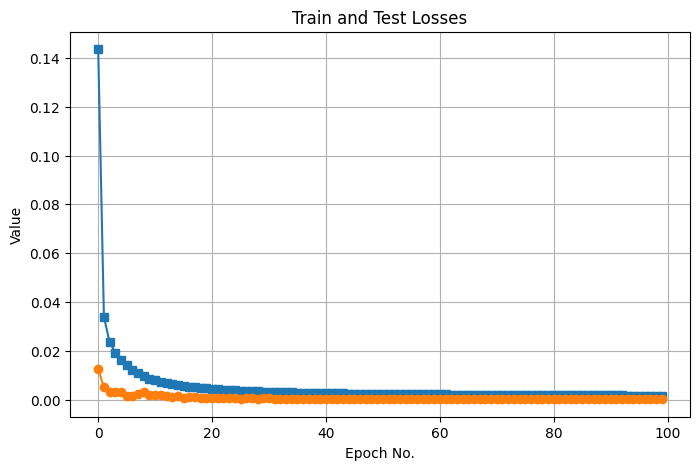

In [19]:
def plot_losses(train_losses, test_losses):
    plt.figure(figsize=(8, 5))
    plt.plot(train_losses, marker="s")  # Plot the list with markers
    plt.plot(test_losses, marker="o")  # Plot the list with markers
    plt.title("Train and Test Losses")
    plt.xlabel("Epoch No.")
    plt.ylabel("Value")
    plt.grid(True)

    # Show the plot
    plt.show()


plot_losses(train_losses, test_losses)

In [ ]:
# save to disk


## Testing it out

Let's see how good our model's predictions are. First, notice that although our final loss was 1.71e-4, we still have to denormalize our model outputs when doing inference, so the "true" MSE loss (with respect to the original, unstandardized data) would be the current MSE loss times the outputs' standard deviation squared, or in this case, about 7.48e-7.

First, let's load our model from disk (we already have it in main memory but let's pretend we didn't):

In [ ]:
# instantiate the new model with the same architectural hyperparameters


BasicTransformer(
  (linear1): Linear(in_features=3, out_features=32, bias=True)
  (linear2): Linear(in_features=32, out_features=3, bias=True)
  (input_dropout): Dropout(p=0.1, inplace=False)
  (pos_encoding): SinusoidalPositionalEncoding()
  (layers): ModuleList(
    (0-2): 3 x TransformerLayer(
      (attention): SelfAttention(
        (attention_heads): ModuleList(
          (0-3): 4 x AttentionHead(
            (W_q): Linear(in_features=32, out_features=8, bias=False)
            (W_k): Linear(in_features=32, out_features=8, bias=False)
            (W_v): Linear(in_features=32, out_features=8, bias=False)
          )
        )
        (W_o): Linear(in_features=32, out_features=32, bias=False)
      )
      (MLP): Sequential(
        (0): Linear(in_features=32, out_features=64, bias=True)
        (1): GELU(approximate='none')
        (2): Linear(in_features=64, out_features=32, bias=True)
      )
      (norm1): LayerNorm((32,), eps=1e-05, elementwise_affine=True)
      (norm2): Lay

Let's also get our normalization constants from earlier (We'll need them to denormalize the model outputs):

In [ ]:
with open("normalization_constants.json", "r") as f:
    stats = json.load(f)

# check
print(stats)

{'x_mean': 0.0005035785143263638, 'x_std': 0.9999176859855652, 'y_mean': 0.0625, 'y_std': 0.06605560332536697}


We need a helper function to plot a sequence of vectors as a matrix so that we can visualize what's going on:

In [27]:
def plot_vectors(sequence):
    matrix = sequence.numpy()

    # Plot the matrix
    plt.imshow(matrix, cmap="RdBu", interpolation="none")
    plt.colorbar()
    plt.title("Vectors")

    plt.tight_layout()
    plt.show()

Great, now let's test out our model on some sample data:

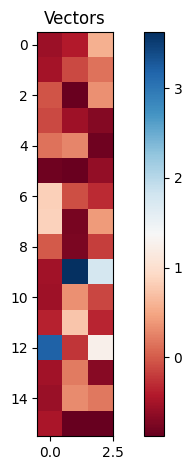

In [ ]:
# get the last element


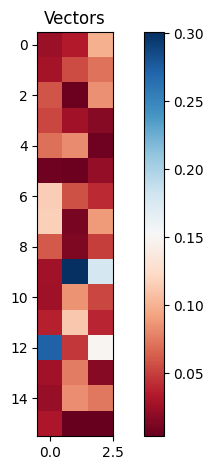

In [ ]:
# get our model's predictions for this sample
# with torch.no_grad():
# we have to play around with some singleton dimensions to get it in the right format
# remember to deal with normalization/denormalization to go back to the original distribution!



Yay! As you can see, (although it's not perfect) the model predictions are pretty close to the true outputs. And with that, we have trained a transformer to model the feature-wise softmax function!

*Thank you all for attending this workshop!*